# <center>Задача 9. Классические методы для графов</center>

In [1]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

np.random.seed(42)
sns.set_style('whitegrid')
%matplotlib inline

### Загрузка данных

В работе используется датасет `REDDIT-BINARY` из коллекции TUDataset --- набор графов для бинарной классификации: каждый граф соответствует обсуждению на Reddit.

Source: [TU Dortmund Graph Kernel Datasets](https://chrsmrrs.github.io/datasets/docs/datasets/).

In [2]:
DATASET_NAME = 'REDDIT-BINARY'
DATA_DIR = Path('data/tudataset')
DATASET_DIR = DATA_DIR / DATASET_NAME
ZIP_PATH = DATA_DIR / f'{DATASET_NAME}.zip'
DATASET_URL = 'https://www.chrsmrrs.com/graphkerneldatasets/REDDIT-BINARY.zip'

DATA_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    if not ZIP_PATH.exists():
        urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as archive:
        archive.extractall(DATA_DIR)

In [3]:
def read_tudataset(name, root):
    base = Path(root) / name
    graph_indicator_path = base / f'{name}_graph_indicator.txt'
    graph_labels_path = base / f'{name}_graph_labels.txt'
    edges_path = base / f'{name}_A.txt'
    
    graph_indicator = []
    with open(graph_indicator_path) as f:
        for line in f:
            graph_indicator.append(int(line.strip()))
    
    graph_labels = []
    with open(graph_labels_path) as f:
        for line in f:
            graph_labels.append(int(line.strip()))
    
    graphs = [nx.Graph() for _ in graph_labels]
    
    for node_id, graph_id in enumerate(graph_indicator, start=1):
        graphs[graph_id - 1].add_node(node_id)
    
    with open(edges_path) as f:
        for line in f:
            u, v = line.strip().split(',')
            u = int(u)
            v = int(v)
            graph_id = graph_indicator[u - 1] - 1
            if graph_indicator[v - 1] - 1 == graph_id and u != v:
                graphs[graph_id].add_edge(u, v)
    
    y = np.array([0 if label == -1 else 1 for label in graph_labels])
    return graphs, y


all_graphs, all_y = read_tudataset(DATASET_NAME, DATA_DIR)
all_sizes = np.array([G.number_of_nodes() for G in all_graphs])

print('All graphs:', len(all_graphs))
print('Class distribution:')
print(pd.Series(all_y).value_counts().sort_index())
print('Min nodes:', all_sizes.min())
print('Max nodes:', all_sizes.max())
print('Mean nodes:', round(all_sizes.mean(), 2))
print('Graphs with more than 1000 nodes:', int((all_sizes > 1000).sum()))
print('Graphs with more than 2000 nodes: ', int((all_sizes > 2000).sum()))

All graphs: 2000
Class distribution:
0    1000
1    1000
Name: count, dtype: int64
Min nodes: 6
Max nodes: 3782
Mean nodes: 429.63
Graphs with more than 1000 nodes: 200
Graphs with more than 2000 nodes:  67


### Выборка графов для экспериментов

In [4]:
def make_subset(graphs, y, n_per_class=60, max_nodes=2500, random_state=42):
    rng = np.random.default_rng(random_state)
    result_idx = []
    sizes = np.array([G.number_of_nodes() for G in graphs])
    
    for label in sorted(np.unique(y)):
        candidates = np.where((y == label) & (sizes <= max_nodes))[0]
        chosen = rng.choice(candidates, size=n_per_class, replace=False)
        result_idx.extend(chosen.tolist())
    
    result_idx = np.array(result_idx)
    rng.shuffle(result_idx)
    return [graphs[i] for i in result_idx], y[result_idx]


graphs, y = make_subset(all_graphs, all_y, n_per_class=60, max_nodes=2500, random_state=42)
sizes = np.array([G.number_of_nodes() for G in graphs])

print('Selected graphs:', len(graphs))
print('Class distribution:')
print(pd.Series(y).value_counts().sort_index())
print('Min nodes:', sizes.min())
print('Max nodes:', sizes.max())
print('Mean nodes:', round(sizes.mean(), 2))

Selected graphs: 120
Class distribution:
0    60
1    60
Name: count, dtype: int64
Min nodes: 14
Max nodes: 2198
Mean nodes: 385.92


### Визуализация графов

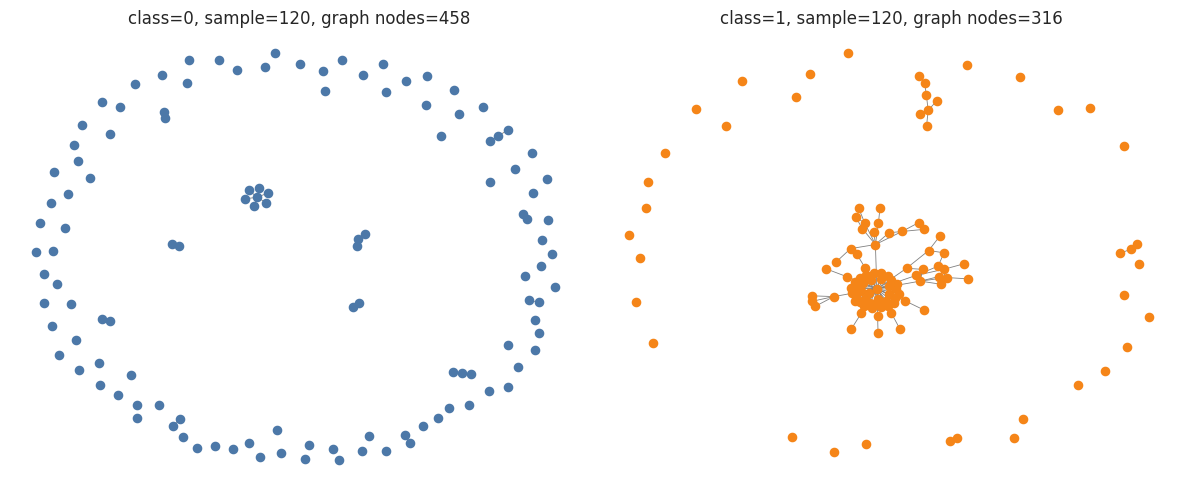

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, label in zip(axes, [0, 1]):
    graph_id = np.where(y == label)[0][0]
    G = graphs[graph_id]
    rng = np.random.default_rng(42 + label)
    sample_size = min(120, G.number_of_nodes())
    nodes = rng.choice(list(G.nodes()), size=sample_size, replace=False)
    H = G.subgraph(nodes).copy()
    pos = nx.spring_layout(H, seed=42)
    color = '#4C78A8' if label == 0 else '#F58518'
    nx.draw_networkx(
        H,
        pos=pos,
        ax=ax,
        with_labels=False,
        node_size=35,
        node_color=color,
        edge_color='gray',
        width=0.6
    )
    ax.set_title(f'class={label}, sample={sample_size}, graph nodes={G.number_of_nodes()}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### EDA

In [6]:
def largest_component(G):
    if nx.is_connected(G):
        return G
    nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(nodes).copy()


def sample_avg_shortest_path(G, sample_size=30, seed=42):
    H = largest_component(G)
    rng = np.random.default_rng(seed)
    nodes = list(H.nodes())
    sources = rng.choice(nodes, size=min(sample_size, len(nodes)), replace=False)
    total = 0
    count = 0
    
    for source in sources:
        lengths = nx.single_source_shortest_path_length(H, int(source))
        total += sum(lengths.values())
        count += len(lengths) - 1
    
    return total / count


rows = []

for graph_id, (G, label) in enumerate(zip(graphs, y)):
    H = largest_component(G)
    rows.append({
        'class': label,
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'density': nx.density(G),
        'largest_component_nodes': H.number_of_nodes(),
        'approx_diameter': nx.approximation.diameter(H),
        'sample_avg_shortest_path': sample_avg_shortest_path(H, seed=graph_id),
        'avg_clustering': nx.average_clustering(G)
    })

info = pd.DataFrame(rows)

print('First rows:')
display(info.head())

print('Mean graph statistics by class:')
display(info.groupby('class').mean().round(3))

First rows:


,class,nodes,edges,density,largest_component_nodes,approx_diameter,sample_avg_shortest_path,avg_clustering
0,1,316,452,0.009082,316,9,3.605926,0.058979
1,0,458,475,0.004539,458,11,3.676368,0.004498
2,0,378,462,0.006484,376,10,3.762578,0.120795
3,0,382,450,0.006184,382,10,3.754243,0.019109
4,0,1547,1825,0.001526,1539,14,4.064586,0.028883


Mean graph statistics by class:


,nodes,edges,density,largest_component_nodes,approx_diameter,sample_avg_shortest_path,avg_clustering
class,,,,,,,
0,491.15,578.500,0.009,488.000,10.833,3.633,0.046
1,280.70,337.733,0.029,276.883,9.183,3.482,0.040


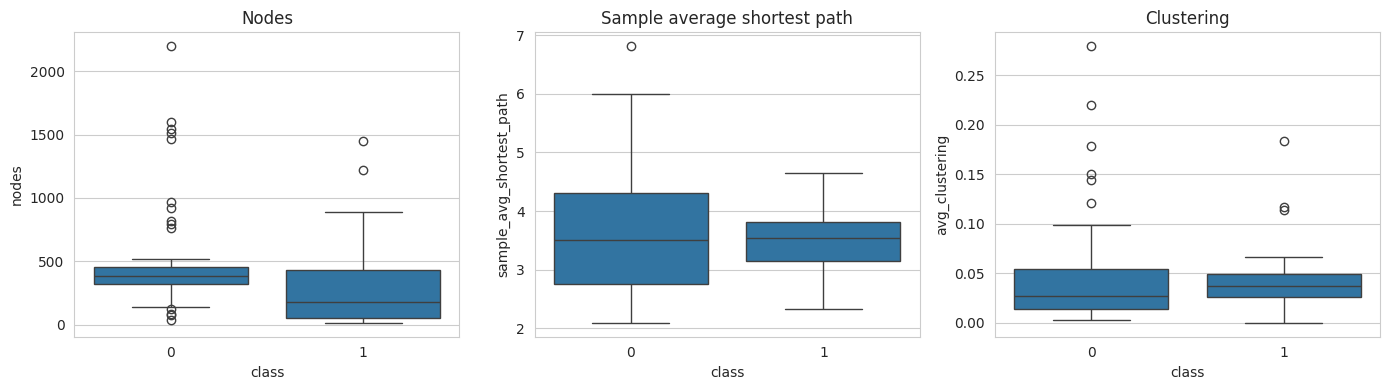

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=info, x='class', y='nodes', ax=axes[0])
axes[0].set_title('Nodes')

sns.boxplot(data=info, x='class', y='sample_avg_shortest_path', ax=axes[1])
axes[1].set_title('Sample average shortest path')

sns.boxplot(data=info, x='class', y='avg_clustering', ax=axes[2])
axes[2].set_title('Clustering')

plt.tight_layout()
plt.show()

**Промежуточный вывод:**

В выбранной подвыборке классы сбалансированы. Размеры графов отличаются, поэтому перед обучением полезно проанализировать базовые структурные характеристики: количество вершин, среднюю длину кратчайшего пути и коэффициент кластеризации.

### Ядро кратчайших путей

Для каждого графа строится вектор из количества кратчайших путей разной длины: длины `1`, `2`, `3` и т.д.

Ядро между двумя графами вычисляется как скалярное произведение таких векторов

In [8]:
def shortest_path_feature(G):
    if 'sp_feature' in G.graph:
        return G.graph['sp_feature']
    
    counts = Counter()
    H = largest_component(G)
    
    for source, lengths in nx.shortest_path_length(H):
        for target, dist in lengths.items():
            if source < target:
                counts[dist] += 1
    
    G.graph['sp_feature'] = counts
    return counts


def counters_to_matrix(counters, keys=None):
    if keys is None:
        keys = sorted({key for counter in counters for key in counter.keys()})
    
    X = np.zeros((len(counters), len(keys)))
    
    for i, counter in enumerate(counters):
        for j, key in enumerate(keys):
            X[i, j] = counter.get(key, 0)
    
    return X, keys


def normalize_features(X_train, X_test):
    train_norm = np.linalg.norm(X_train, axis=1, keepdims=True)
    test_norm = np.linalg.norm(X_test, axis=1, keepdims=True)
    train_norm[train_norm == 0] = 1
    test_norm[test_norm == 0] = 1
    return X_train / train_norm, X_test / test_norm


def shortest_path_kernel(train_graphs, test_graphs, normalize=True):
    train_features = [shortest_path_feature(G) for G in train_graphs]
    test_features = [shortest_path_feature(G) for G in test_graphs]
    keys = sorted({key for counter in train_features + test_features for key in counter.keys()})
    
    X_train, _ = counters_to_matrix(train_features, keys)
    X_test, _ = counters_to_matrix(test_features, keys)
    
    if normalize:
        X_train, X_test = normalize_features(X_train, X_test)
    
    K_train = X_train @ X_train.T
    K_test = X_test @ X_train.T
    
    return K_train, K_test

In [9]:
example_features = shortest_path_feature(graphs[0])
print('Example features for one graph:')
print(dict(sorted(example_features.items())))

K_demo_train, K_demo_test = shortest_path_kernel(graphs[:5], graphs[5:8])
print('K_train shape:', K_demo_train.shape)
print('K_test shape:', K_demo_test.shape)

Example features for one graph:
{1: 452, 2: 10018, 3: 15624, 4: 14752, 5: 6922, 6: 1716, 7: 264, 8: 20, 9: 2}
K_train shape: (5, 5)
K_test shape: (3, 5)


### Обучение SVC с ядром кратчайших путей

In [10]:
graph_train_val, graph_test, y_train_val, y_test = train_test_split(
    graphs, y, test_size=0.25, random_state=42, stratify=y
)

graph_train, graph_val, y_train, y_val = train_test_split(
    graph_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print('train:', len(graph_train))
print('val:', len(graph_val))
print('test:', len(graph_test))

train: 67
val: 23
test: 30


In [11]:
def make_metrics(y_true, y_pred, scores, kernel_name):
    return {
        'kernel': kernel_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, scores)
    }


def fit_and_score(K_train, K_val, y_train, y_val, C, kernel_name):
    model = SVC(kernel='precomputed', C=C)
    model.fit(K_train, y_train)
    pred = model.predict(K_val)
    scores = model.decision_function(K_val)
    metrics = make_metrics(y_val, pred, scores, kernel_name)
    metrics['C'] = C
    return model, metrics

In [12]:
K_train_sp, K_val_sp = shortest_path_kernel(graph_train, graph_val)

sp_results = []
best_sp = None

for C in [0.01, 0.1, 1, 10, 100]:
    model, metrics = fit_and_score(K_train_sp, K_val_sp, y_train, y_val, C, 'Shortest path')
    sp_results.append(metrics)
    
    if best_sp is None or metrics['f1'] > best_sp['metrics']['f1']:
        best_sp = {'C': C, 'model': model, 'metrics': metrics}

sp_val_table = pd.DataFrame(sp_results).sort_values('f1', ascending=False)
display(sp_val_table.round(3))

print('Best C:', best_sp['C'])

,kernel,accuracy,precision,recall,f1,roc_auc,C
4,Shortest path,0.826,0.733,1.000,0.846,0.894,100.00
3,Shortest path,0.783,0.750,0.818,0.783,0.902,10.00
2,Shortest path,0.609,0.556,0.909,0.690,0.864,1.00
0,Shortest path,0.478,0.478,1.000,0.647,0.780,0.01
1,Shortest path,0.478,0.478,1.000,0.647,0.826,0.10


Best C: 100


In [13]:
K_train_val_sp, K_test_sp = shortest_path_kernel(graph_train_val, graph_test)

sp_model = SVC(kernel='precomputed', C=best_sp['C'])
sp_model.fit(K_train_val_sp, y_train_val)

sp_pred = sp_model.predict(K_test_sp)
sp_scores = sp_model.decision_function(K_test_sp)
sp_metrics = make_metrics(y_test, sp_pred, sp_scores, 'Shortest path')
sp_metrics['C'] = best_sp['C']

print('Test metrics:')
display(pd.DataFrame([sp_metrics]).round(3))

print('Confusion matrix:')
display(pd.DataFrame(confusion_matrix(y_test, sp_pred), index=['true 0', 'true 1'], columns=['pred 0', 'pred 1']))

print(classification_report(y_test, sp_pred))

Test metrics:


,kernel,accuracy,precision,recall,f1,roc_auc,C
0,Shortest path,0.8,0.737,0.933,0.824,0.924,100


Confusion matrix:


,pred 0,pred 1
true 0,10,5
true 1,1,14


              precision    recall  f1-score   support

           0       0.91      0.67      0.77        15
           1       0.74      0.93      0.82        15

    accuracy                           0.80        30
   macro avg       0.82      0.80      0.80        30
weighted avg       0.82      0.80      0.80        30



### Ядро Вейсфейлера-Лемана

Source: [JMLR: Weisfeiler-Lehman Graph Kernels](https://www.jmlr.org/papers/v12/shervashidze11a.html).

На каждой итерации для вершины строится новая метка из ее текущей метки и отсортированного набора меток соседей. После этого граф описывается количеством меток разных типов.

In [14]:
def wl_features(graphs, h=3):
    labels = []
    features = [Counter() for _ in graphs]
    
    for G in graphs:
        labels.append({v: G.degree[v] for v in G.nodes()})
    
    for it in range(h + 1):
        for graph_id, lab in enumerate(labels):
            for value in lab.values():
                features[graph_id][(it, value)] += 1
        
        if it == h:
            break
        
        mapping = {}
        new_labels = []
        
        for G, lab in zip(graphs, labels):
            next_lab = {}
            for v in G.nodes():
                signature = (lab[v], tuple(sorted(lab[u] for u in G.neighbors(v))))
                if signature not in mapping:
                    mapping[signature] = len(mapping)
                next_lab[v] = mapping[signature]
            new_labels.append(next_lab)
        
        labels = new_labels
    
    return features


def wl_kernel(train_graphs, test_graphs, h=3, normalize=True):
    all_graphs = list(train_graphs) + list(test_graphs)
    all_features = wl_features(all_graphs, h=h)
    
    train_features = all_features[:len(train_graphs)]
    test_features = all_features[len(train_graphs):]
    
    keys = sorted({key for counter in all_features for key in counter.keys()})
    X_train, _ = counters_to_matrix(train_features, keys)
    X_test, _ = counters_to_matrix(test_features, keys)
    
    if normalize:
        X_train, X_test = normalize_features(X_train, X_test)
    
    K_train = X_train @ X_train.T
    K_test = X_test @ X_train.T
    
    return K_train, K_test

In [15]:
K_demo_train, K_demo_test = wl_kernel(graphs[:5], graphs[5:8], h=2)
print('K_train shape:', K_demo_train.shape)
print('K_test shape:', K_demo_test.shape)

K_train shape: (5, 5)
K_test shape: (3, 5)


### Обучение SVC с ядром Вейсфейлера-Лемана

In [16]:
wl_results = []
best_wl = None

for h in [1, 2, 3, 4]:
    K_train_wl, K_val_wl = wl_kernel(graph_train, graph_val, h=h)
    
    for C in [0.01, 0.1, 1, 10, 100]:
        model, metrics = fit_and_score(K_train_wl, K_val_wl, y_train, y_val, C, 'WL')
        metrics['h'] = h
        wl_results.append(metrics)
        
        if best_wl is None or metrics['f1'] > best_wl['metrics']['f1']:
            best_wl = {'C': C, 'h': h, 'model': model, 'metrics': metrics}

wl_val_table = pd.DataFrame(wl_results).sort_values('f1', ascending=False)
display(wl_val_table.head(10).round(3))

print('Best parameters:', 'C =', best_wl['C'], ', h =', best_wl['h'])

,kernel,accuracy,precision,recall,f1,roc_auc,C,h
0,WL,0.478,0.478,1.0,0.647,0.371,0.01,1
1,WL,0.478,0.478,1.0,0.647,0.379,0.10,1
2,WL,0.478,0.478,1.0,0.647,0.379,1.00,1
5,WL,0.478,0.478,1.0,0.647,0.379,0.01,2
16,WL,0.478,0.478,1.0,0.647,0.409,0.10,4
6,WL,0.478,0.478,1.0,0.647,0.394,0.10,2
7,WL,0.478,0.478,1.0,0.647,0.394,1.00,2
11,WL,0.478,0.478,1.0,0.647,0.394,0.10,3
10,WL,0.478,0.478,1.0,0.647,0.394,0.01,3
17,WL,0.478,0.478,1.0,0.647,0.409,1.00,4


Best parameters: C = 0.01 , h = 1


In [17]:
K_train_val_wl, K_test_wl = wl_kernel(graph_train_val, graph_test, h=best_wl['h'])

wl_model = SVC(kernel='precomputed', C=best_wl['C'])
wl_model.fit(K_train_val_wl, y_train_val)

wl_pred = wl_model.predict(K_test_wl)
wl_scores = wl_model.decision_function(K_test_wl)
wl_metrics = make_metrics(y_test, wl_pred, wl_scores, 'WL')
wl_metrics['C'] = best_wl['C']
wl_metrics['h'] = best_wl['h']

print('Test metrics:')
display(pd.DataFrame([wl_metrics]).round(3))

print('Confusion matrix:')
display(pd.DataFrame(confusion_matrix(y_test, wl_pred), index=['true 0', 'true 1'], columns=['pred 0', 'pred 1']))

print(classification_report(y_test, wl_pred))

Test metrics:


,kernel,accuracy,precision,recall,f1,roc_auc,C,h
0,WL,0.633,0.583,0.933,0.718,0.764,0.01,1


Confusion matrix:


,pred 0,pred 1
true 0,5,10
true 1,1,14


              precision    recall  f1-score   support

           0       0.83      0.33      0.48        15
           1       0.58      0.93      0.72        15

    accuracy                           0.63        30
   macro avg       0.71      0.63      0.60        30
weighted avg       0.71      0.63      0.60        30



### Сравнение результатов

In [18]:
compare = pd.DataFrame([sp_metrics, wl_metrics])
metric_cols = ['kernel', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'C']
if 'h' in compare.columns:
    metric_cols.append('h')

display(compare[metric_cols].round(3))

,kernel,accuracy,precision,recall,f1,roc_auc,C,h
0,Shortest path,0.800,0.737,0.933,0.824,0.924,100.00,NaN
1,WL,0.633,0.583,0.933,0.718,0.764,0.01,1.0


### Итоговые выводы

В работе был рассмотрен датасет `REDDIT-BINARY` для бинарной классификации графов. Для графов были реализованы два ядра: ядро кратчайших путей и ядро Вейсфейлера-Лемана.

Ядро кратчайших путей описывает граф распределением расстояний между вершинами. Ядро Вейсфейлера-Лемана использует локальную структуру графа через итеративное обновление меток вершин.

По итоговым метрикам на тестовой выборке качество двух подходов различается. На выбранной подвыборке лучший результат показало ядро кратчайших путей.